Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

#IMPORTING THE DATA SET AND LIBARARY

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"F:\ML_project\notebook\data\stud.csv")

In [3]:
df.head() 
# this will show the first 5 records

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

 Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [5]:
#checking missing values
df.isna().sum()
#hence there is no missing values

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
#checking for duplicates values
df.duplicated().sum()
#hence there no duplictes values

0

In [7]:
#check datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
#checking the no of unquie values in each column
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
#check full stastic of data set 
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


exploring data

In [10]:
print("Categories in 'gender' variable:  ",end="")
print(df["gender"].unique())
print("Categories in 'race_ethnicity' variable:  ",end="")
print(df["race_ethnicity"].unique())
print("Categories in 'parental_level_of_education ' variable:  ",end="")
print(df["parental_level_of_education"].unique())
print("Categories in 'lunch' variable:  ",end="")
print(df["lunch"].unique())
print("Categories in 'test_preparation_course' variable:  ",end="")
print(df["test_preparation_course"].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education ' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable:  ['none' 'completed']


In [11]:
#define numericial and categorical features


numeric_features=df.select_dtypes(include=["number"]).columns
categorical_features=df.select_dtypes(include=['object']).columns

In [12]:
print(f"we have {len(numeric_features)} numeric_features :{numeric_features} ")
print(f"we have {len(categorical_features)} categorical_feature: {categorical_features} ")

we have 3 numeric_features :Index(['math_score', 'reading_score', 'writing_score'], dtype='object') 
we have 5 categorical_feature: Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object') 


In [13]:
df.head(1)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74


In [14]:
#adding column for total score  and average
##feature engg
df['Total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['Average_score']=df["Total_score"]/3
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
df[df['reading_score'] == 100].shape[0]#shape will give u (rows,column) but shpe[0] will give u only rows count
                                                                            #shape[1] will give u column count


17

In [16]:
reading_full = df[df['reading_score'] == 100].shape[0]#"df[df['reading_score'] == 100]" this statement will filter out who has scored 100
writing_full = df[df['writing_score'] == 100].shape[0]#"['Average_score'].count()" this will count 
math_full = df[df['math_score'] == 100].shape[0]

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [17]:
reading_less_20 = df[df['reading_score'] <= 20].shape[0]
writing_less_20 = df[df['writing_score'] <= 20].shape[0]
math_less_20 = df[df['math_score'] <= 20].shape[0]

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

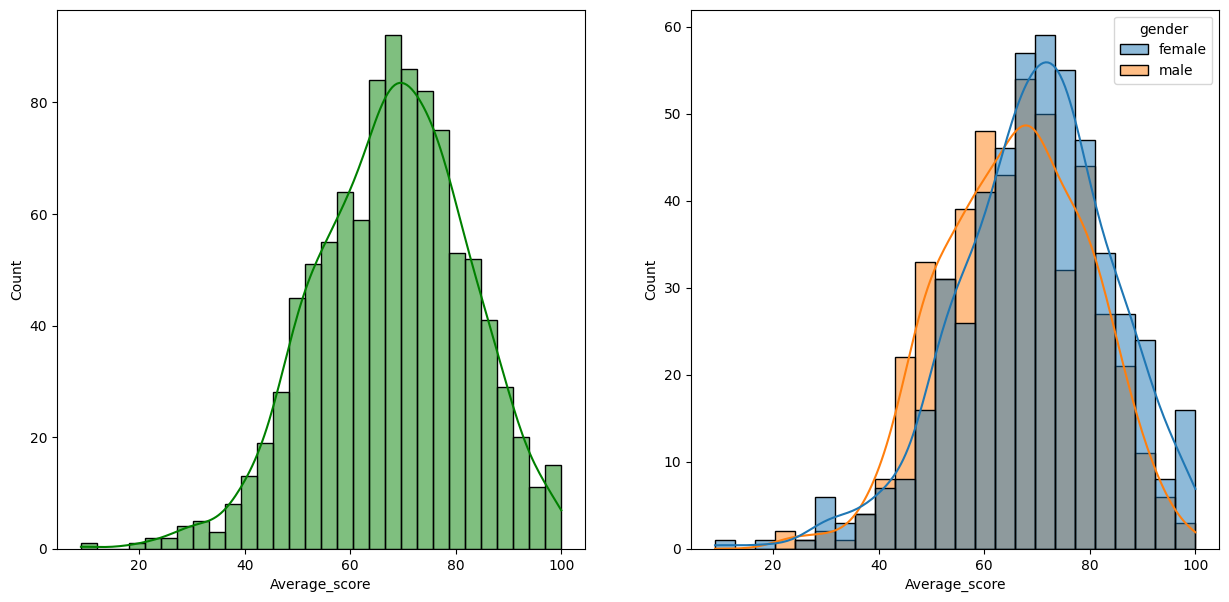

In [18]:
plt.subplots(1, 2, figsize=(15, 7))                                     #(1,2, this will create 1 rows and 2 column
                                                                        #fig=The entire figure (canvas)
                                                                        #Since you asked for 2 plots → axs becomes a list/array:
                                                                        #figsize=(15, 7)Size of the whole figure
                                                                                    #15 → width
                                                                                    #7 → height
plt.subplot(121)
                                                                        #plt.subplot(121)
                                                                        #1 row
                                                                        #2 columns
                                                                        #select 1st plot
sns.histplot(data=df,x='Average_score',bins=30,kde=True,color='g')
                                                                        #'''
                                                                        #histplot → histogram
                                                                        #x='Average_score' → what to plot
                                                                        #bins=30 → divide data into 30 bars
                                                                        #kde=True → smooth curve line (distribution curve)
                                                                        #color='g' → green color
                                                                        #'''
plt.subplot(122)
sns.histplot(data=df,x='Average_score',kde=True,hue='gender')           #hue='gender' → splits data by gender
plt.show()

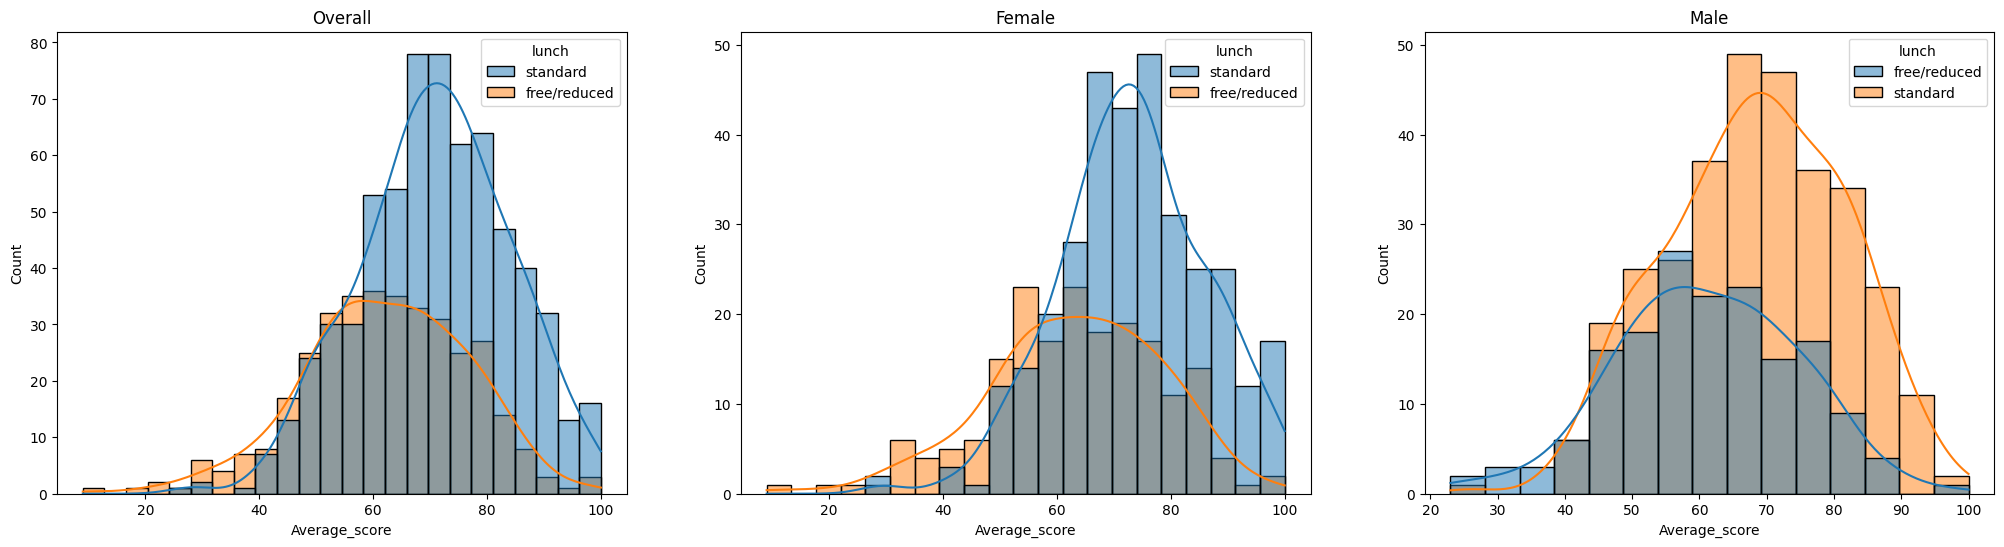

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(25,6))

sns.histplot(data=df, x='Average_score', kde=True, hue='lunch', ax=axs[0])
axs[0].set_title("Overall")

sns.histplot(data=df[df.gender=='female'], x='Average_score', kde=True, hue='lunch', ax=axs[1])
axs[1].set_title("Female")

sns.histplot(data=df[df.gender=='male'], x='Average_score', kde=True, hue='lunch', ax=axs[2])
axs[2].set_title("Male")

plt.show()

#### 4.2 Maximumum score of students in all three subjects

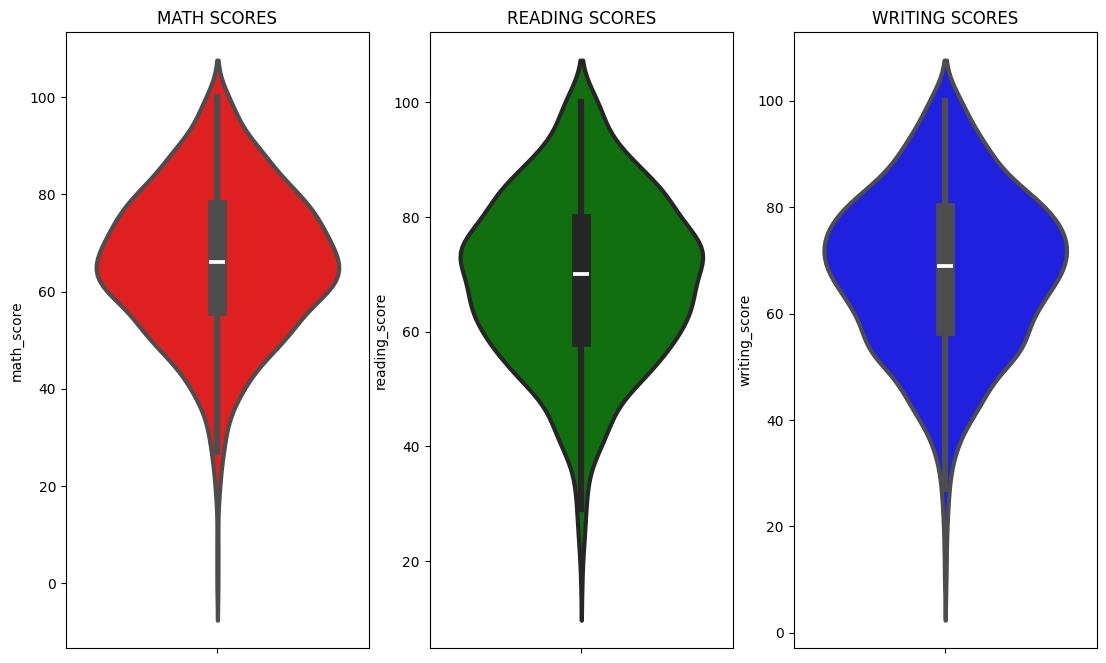

In [20]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

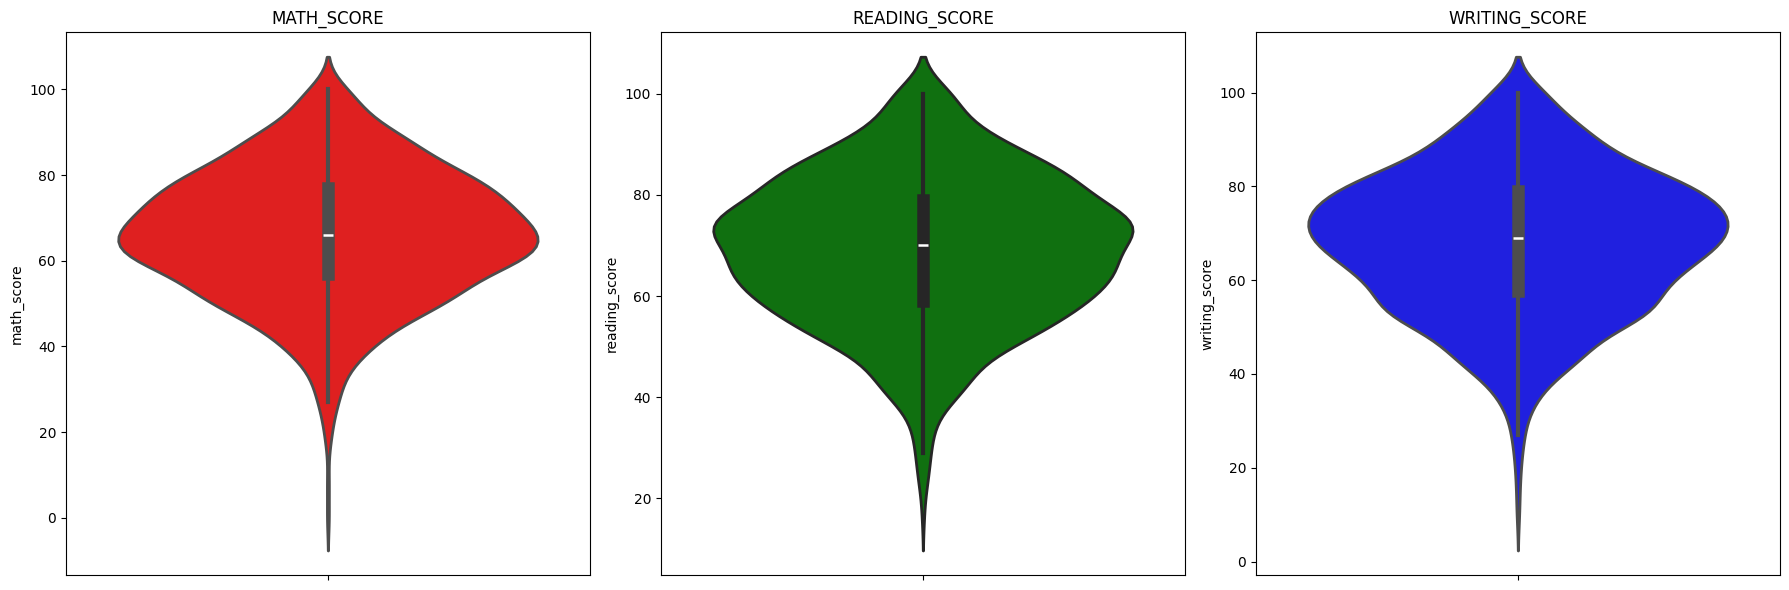

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

scores = ['math_score', 'reading_score', 'writing_score']
colors = ['red', 'green', 'blue']

for i, score in enumerate(scores):
    sns.violinplot(y=score, data=df, color=colors[i], linewidth=2, ax=axs[i])
    axs[i].set_title(score.upper())

plt.tight_layout()
plt.show()

In [22]:
df.head(1)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667


#### 4.3 Multivariate analysis using pieplotm

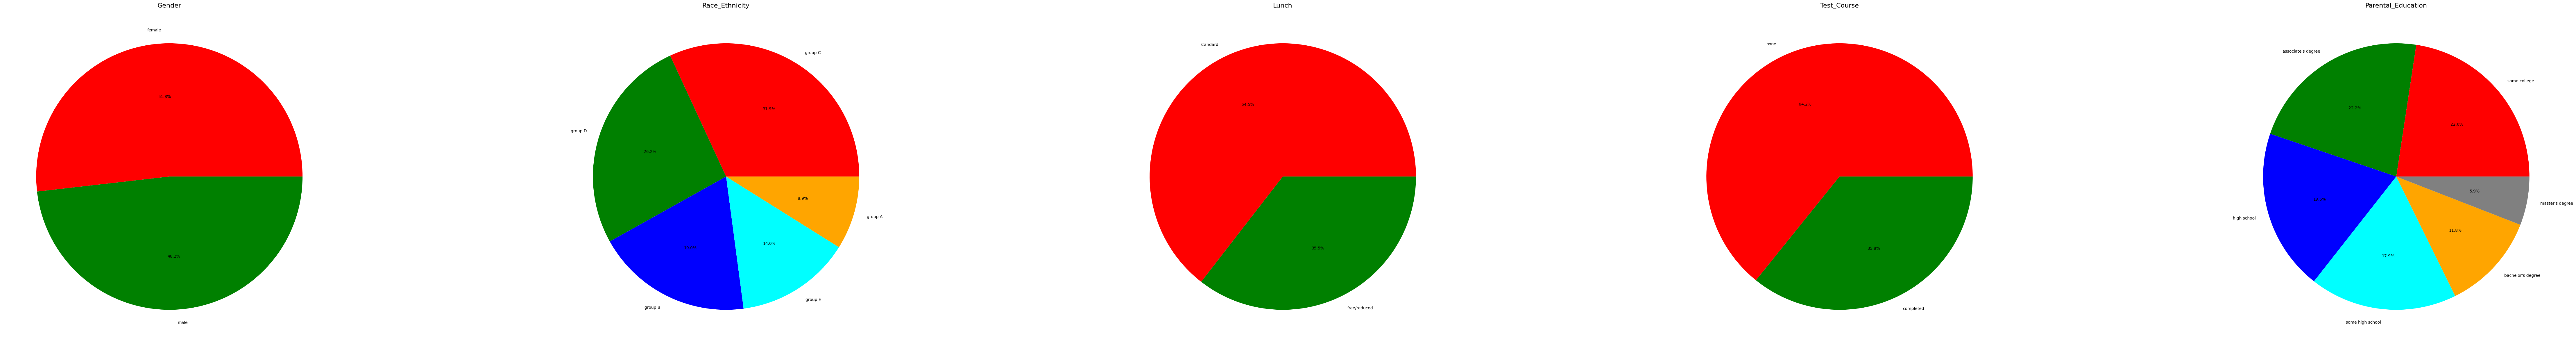

In [23]:
fig, axs = plt.subplots(1, 5, figsize=(100, 12))

columns = [
    'gender',
    'race_ethnicity',
    'lunch',
    'test_preparation_course',
    'parental_level_of_education'
]

titles = [
    'Gender',
    'Race_Ethnicity',
    'Lunch',
    'Test_Course',
    'Parental_Education'
]

colors_list = [
    ['red','green'],
    ['red','green','blue','cyan','orange'],
    ['red','green'],
    ['red','green'],
    ['red','green','blue','cyan','orange','grey']
]

for i, col in enumerate(columns):
    size = df[col].value_counts()
    
    axs[i].pie(
        size,
        labels=size.index,   # automatically takes correct labels
        colors=colors_list[i],
        autopct='%1.1f%%'
    )
    
    axs[i].set_title(titles[i], fontsize=16)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

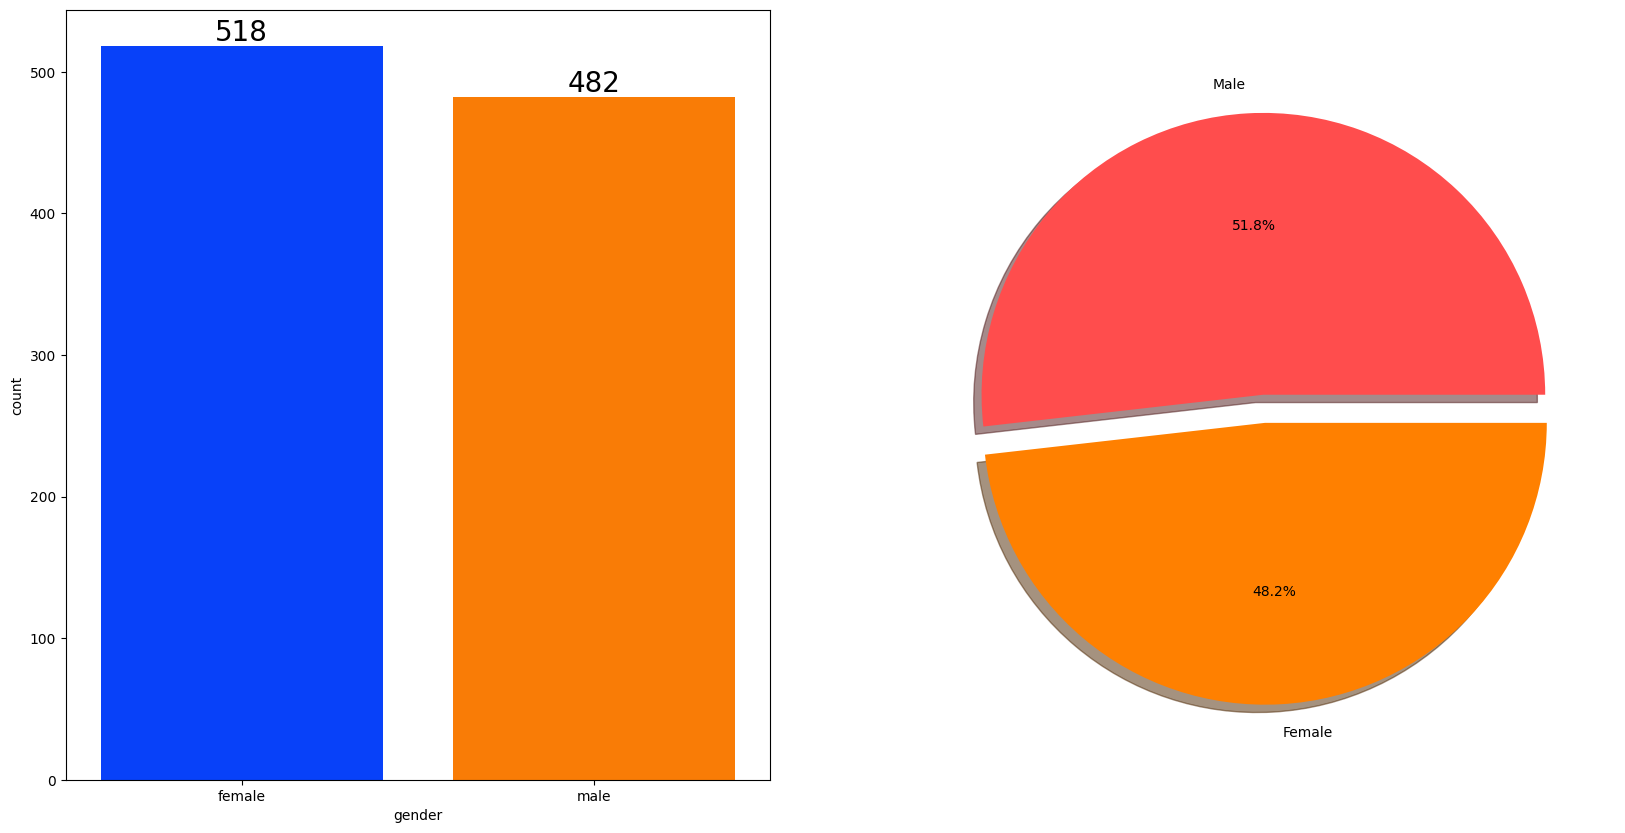

In [24]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [25]:
df.groupby('gender').count()

,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
gender,,,,,,,,,
female,518,518,518,518,518,518,518,518,518
male,482,482,482,482,482,482,482,482,482


In [26]:
gender_group=df.groupby('gender').mean(numeric_only=True)

In [27]:
df.dtypes

gender                          object
race_ethnicity                  object
parental_level_of_education     object
lunch                           object
test_preparation_course         object
math_score                       int64
reading_score                    int64
writing_score                    int64
Total_score                      int64
Average_score                  float64
dtype: object

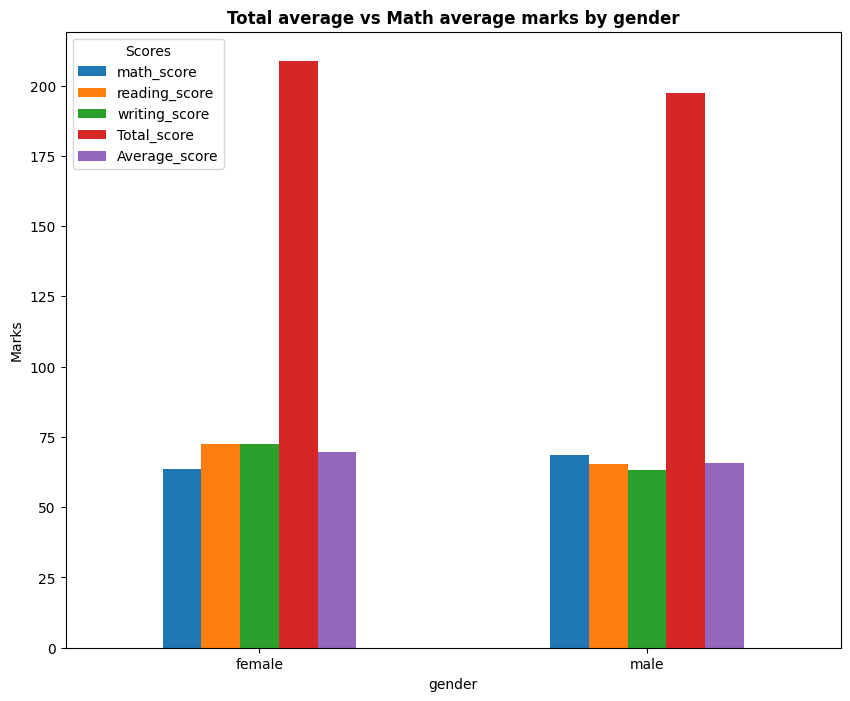

In [28]:
gender_group.plot(kind='bar', figsize=(10, 8))

plt.ylabel("Marks")
plt.title("Total average vs Math average marks by gender", fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title="Scores")
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

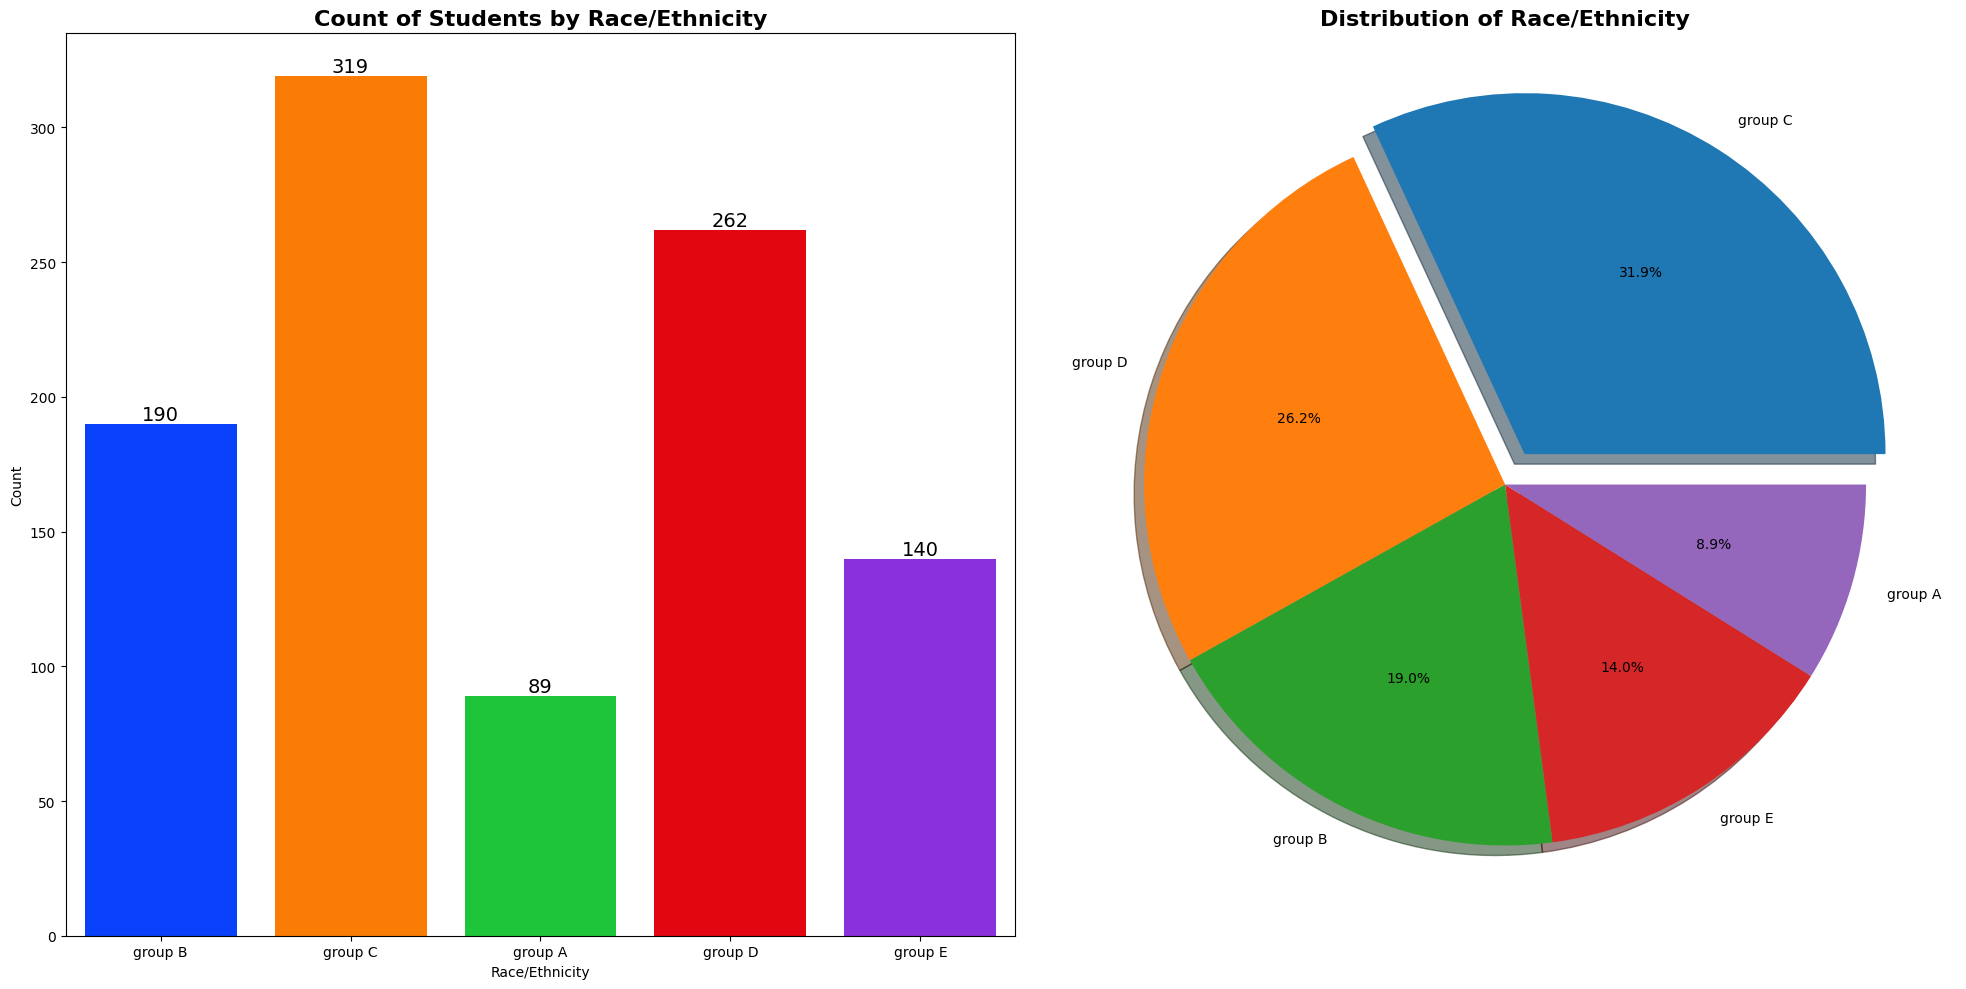

In [29]:
# Prepare data once ✅
race_counts = df['race_ethnicity'].value_counts()

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# 🎯 1. Countplot
sns.countplot(
    x='race_ethnicity',
    data=df,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

# Add labels on bars
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=14)

ax[0].set_title("Count of Students by Race/Ethnicity", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Race/Ethnicity")
ax[0].set_ylabel("Count")

# 🎯 2. Pie chart (use ax[1] properly ✅)
ax[1].pie(
    race_counts,
    labels=race_counts.index,
    explode=[0.1] + [0]*(len(race_counts)-1),  # dynamic explode
    autopct='%1.1f%%',
    shadow=True
)

ax[1].set_title("Distribution of Race/Ethnicity", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

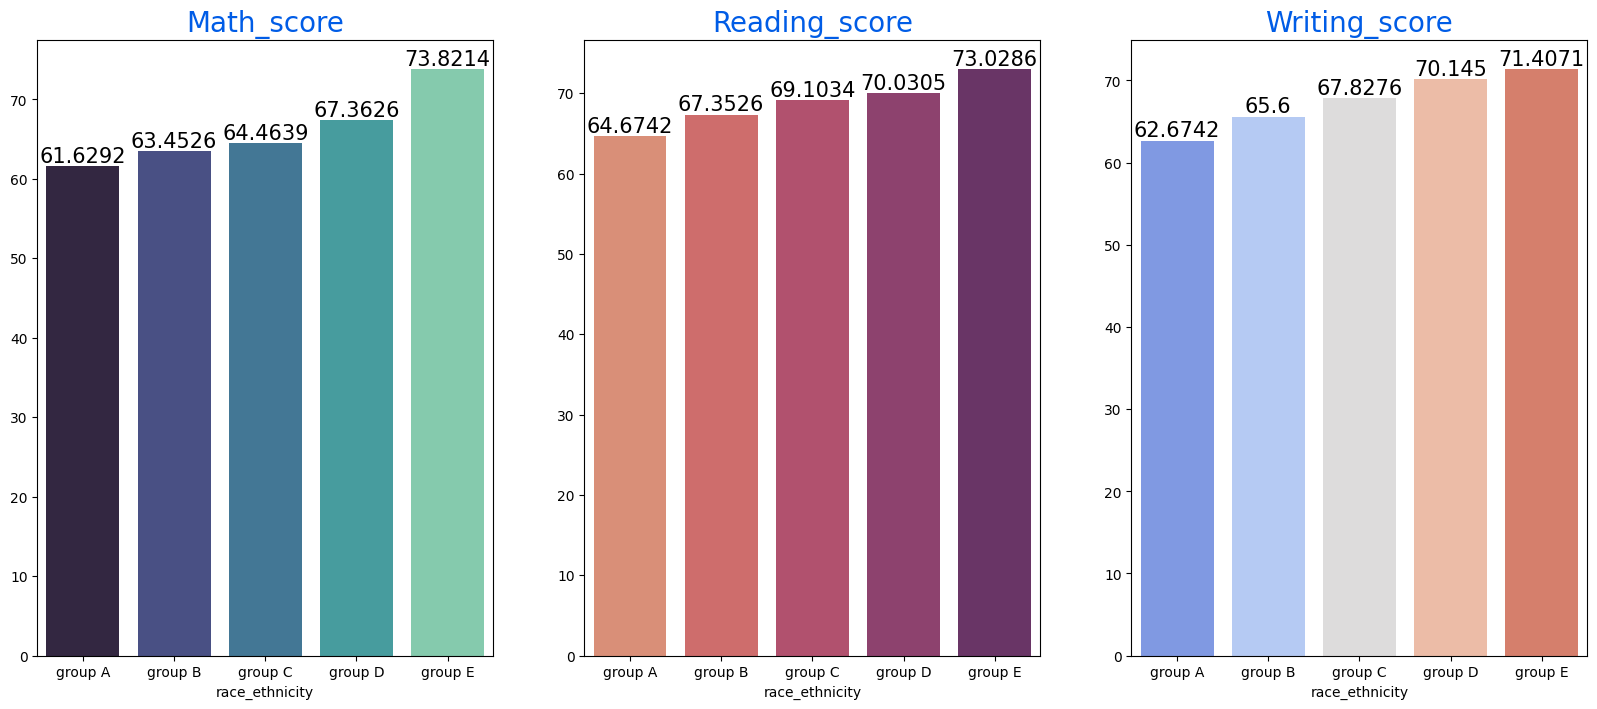

In [30]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math_score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading_score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing_score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

In [31]:
df.dtypes

gender                          object
race_ethnicity                  object
parental_level_of_education     object
lunch                           object
test_preparation_course         object
math_score                       int64
reading_score                    int64
writing_score                    int64
Total_score                      int64
Average_score                  float64
dtype: object

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

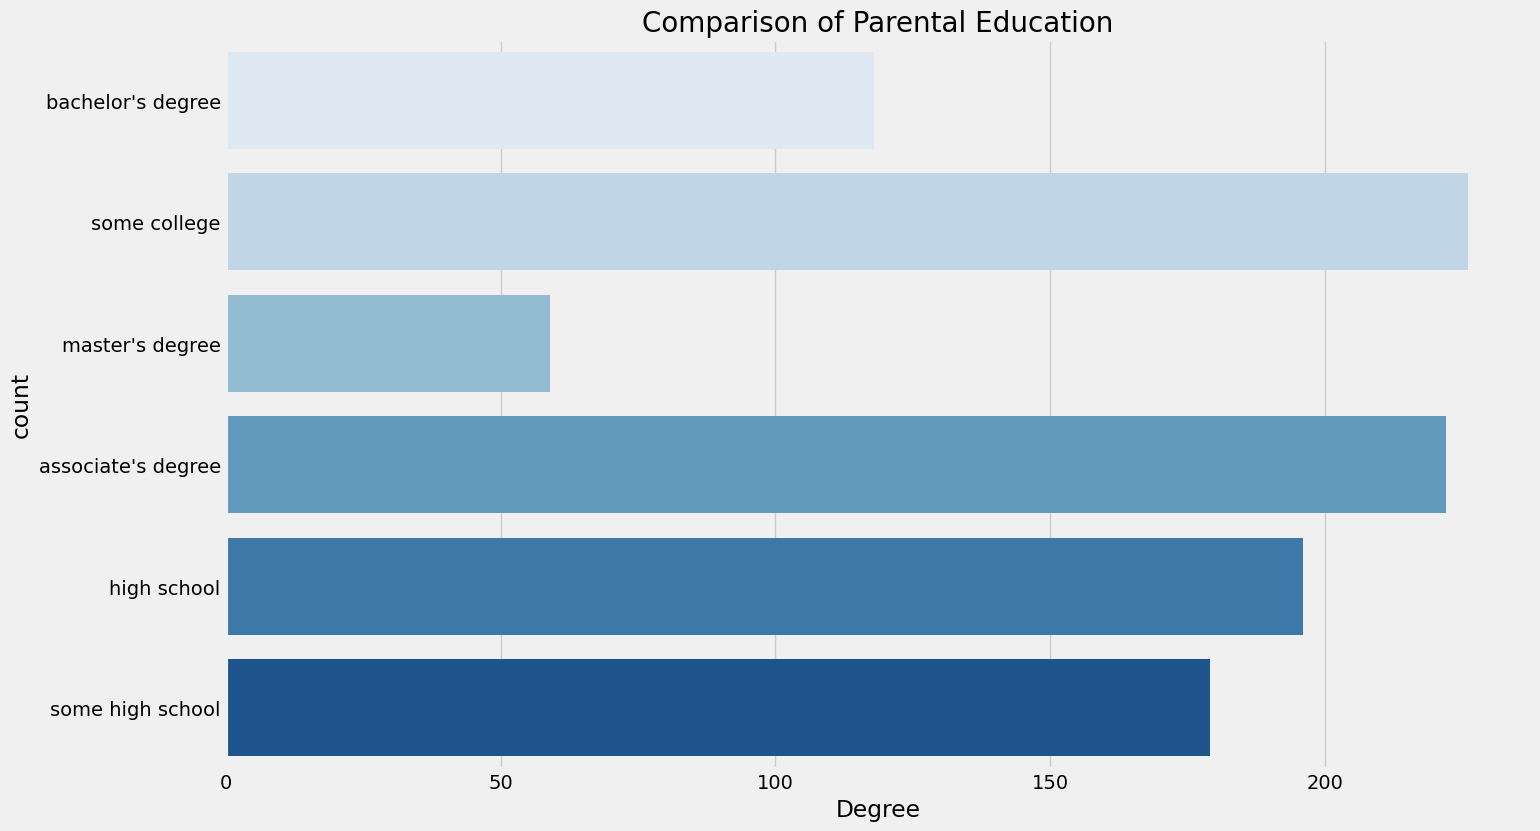

In [32]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

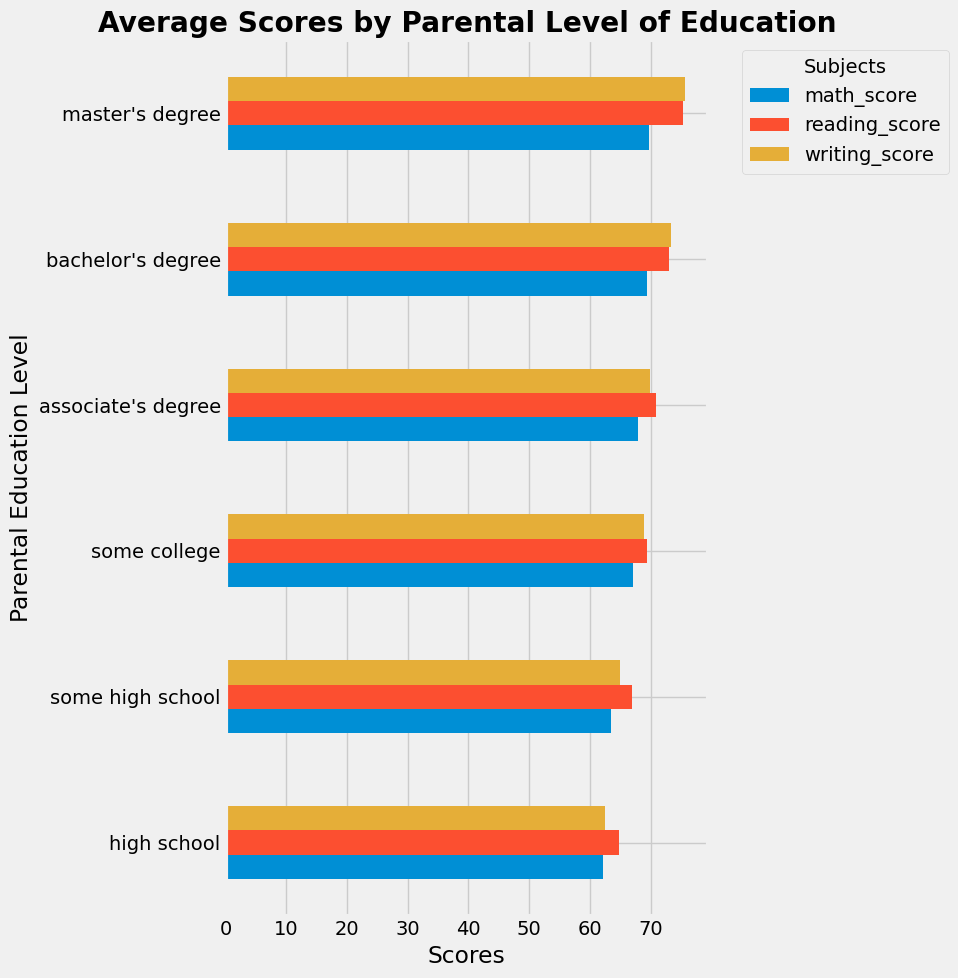

In [33]:
import matplotlib.pyplot as plt

# Select only required numeric columns
cols = ['math_score', 'reading_score', 'writing_score']

grouped = (
    df.groupby('parental_level_of_education')[cols]
    .mean()
    .sort_values(by='math_score')  # optional: better visualization
)

# Plot
grouped.plot(kind='barh', figsize=(10, 10))

plt.title("Average Scores by Parental Level of Education", fontweight='bold')
plt.xlabel("Scores")
plt.ylabel("Parental Education Level")

plt.legend(title="Subjects", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

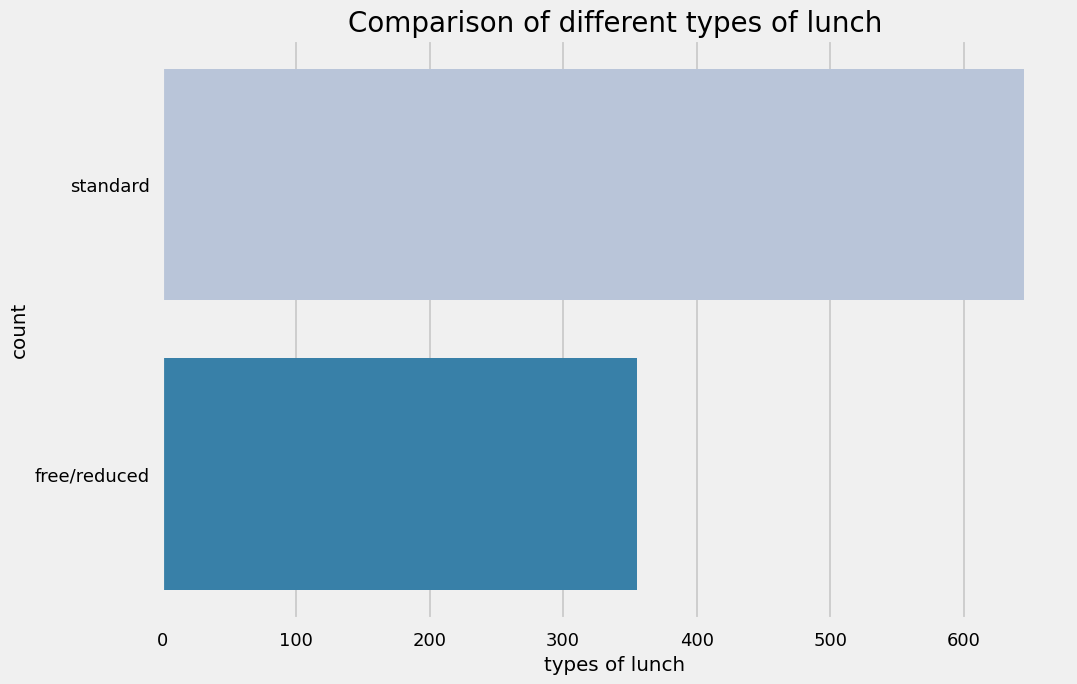

In [34]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

In [35]:
df.dtypes


gender                          object
race_ethnicity                  object
parental_level_of_education     object
lunch                           object
test_preparation_course         object
math_score                       int64
reading_score                    int64
writing_score                    int64
Total_score                      int64
Average_score                  float64
dtype: object

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

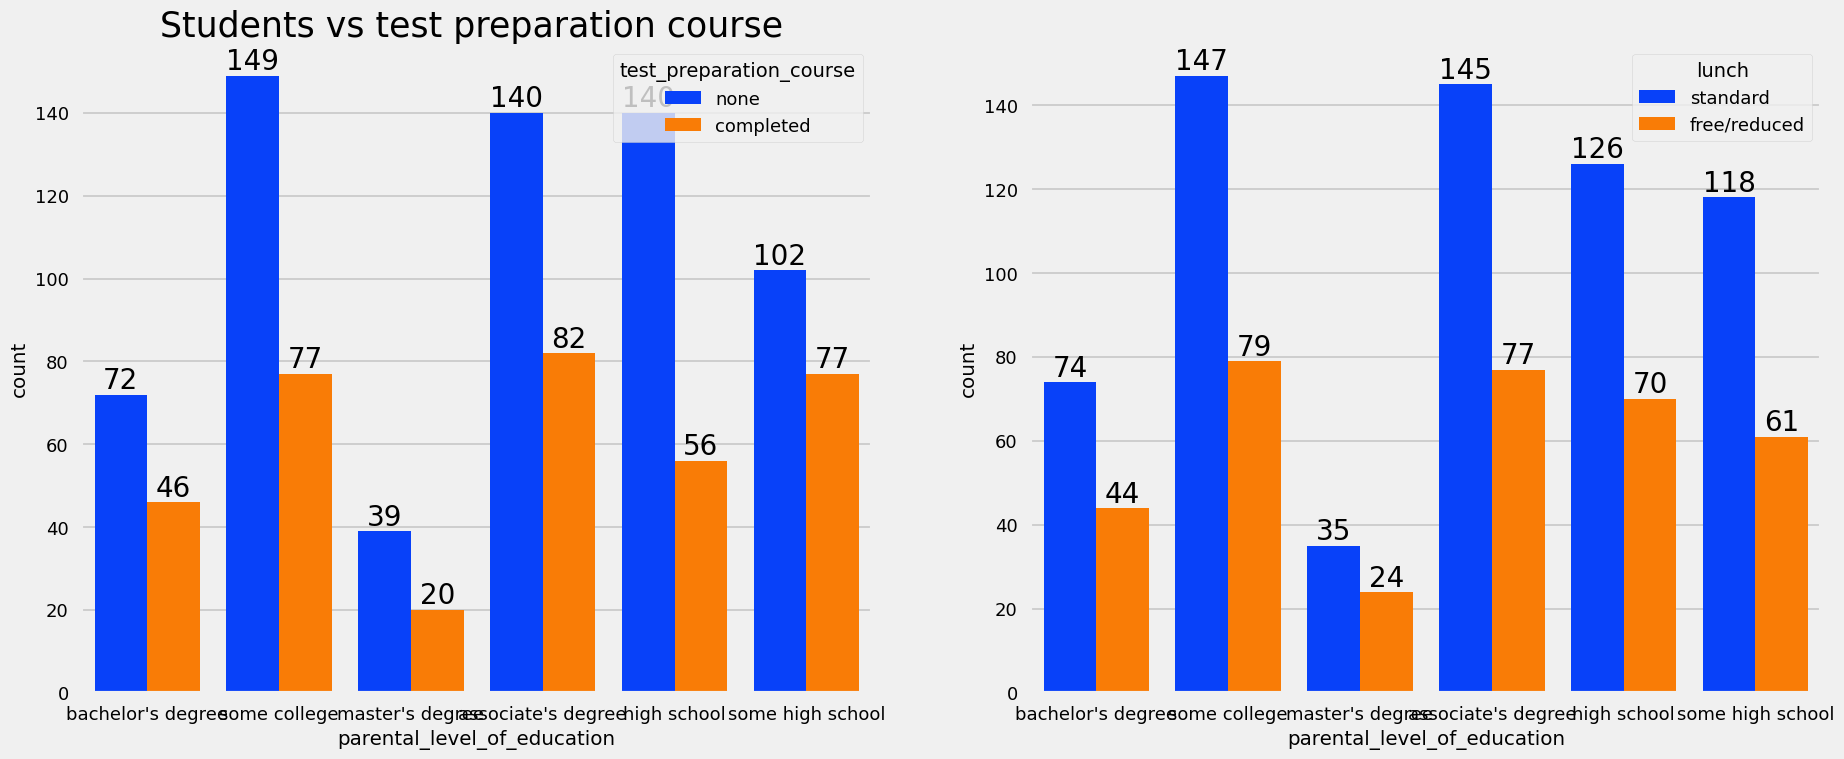

In [36]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing_score'>

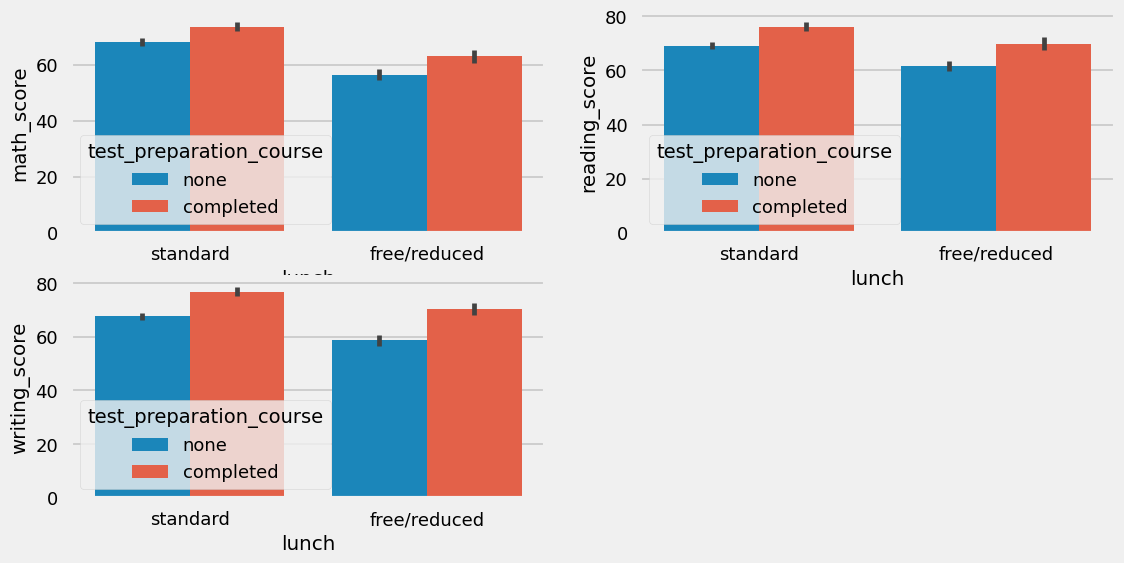

In [37]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

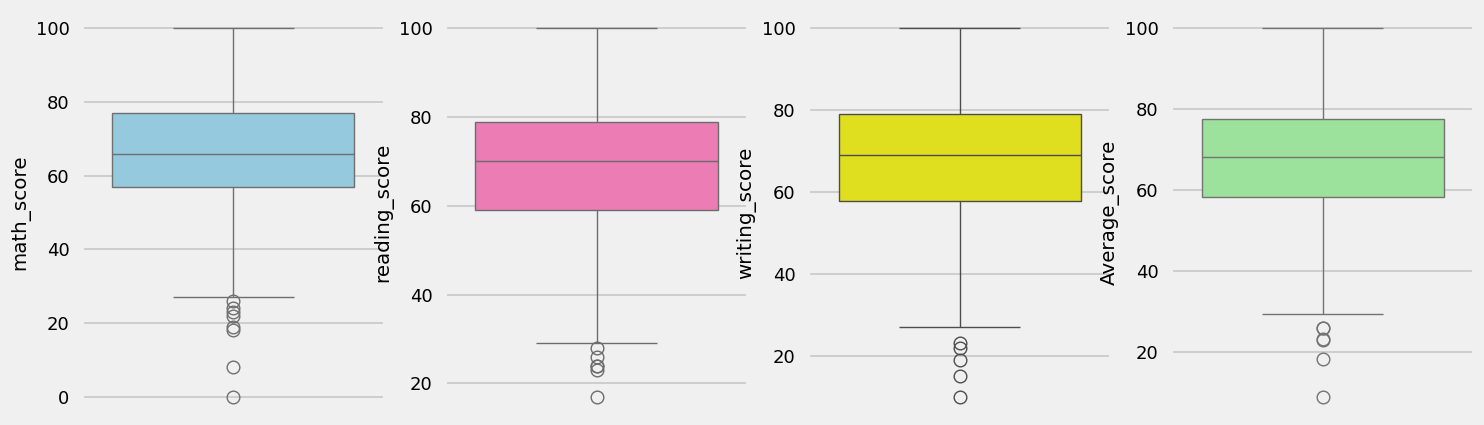

In [38]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['Average_score'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

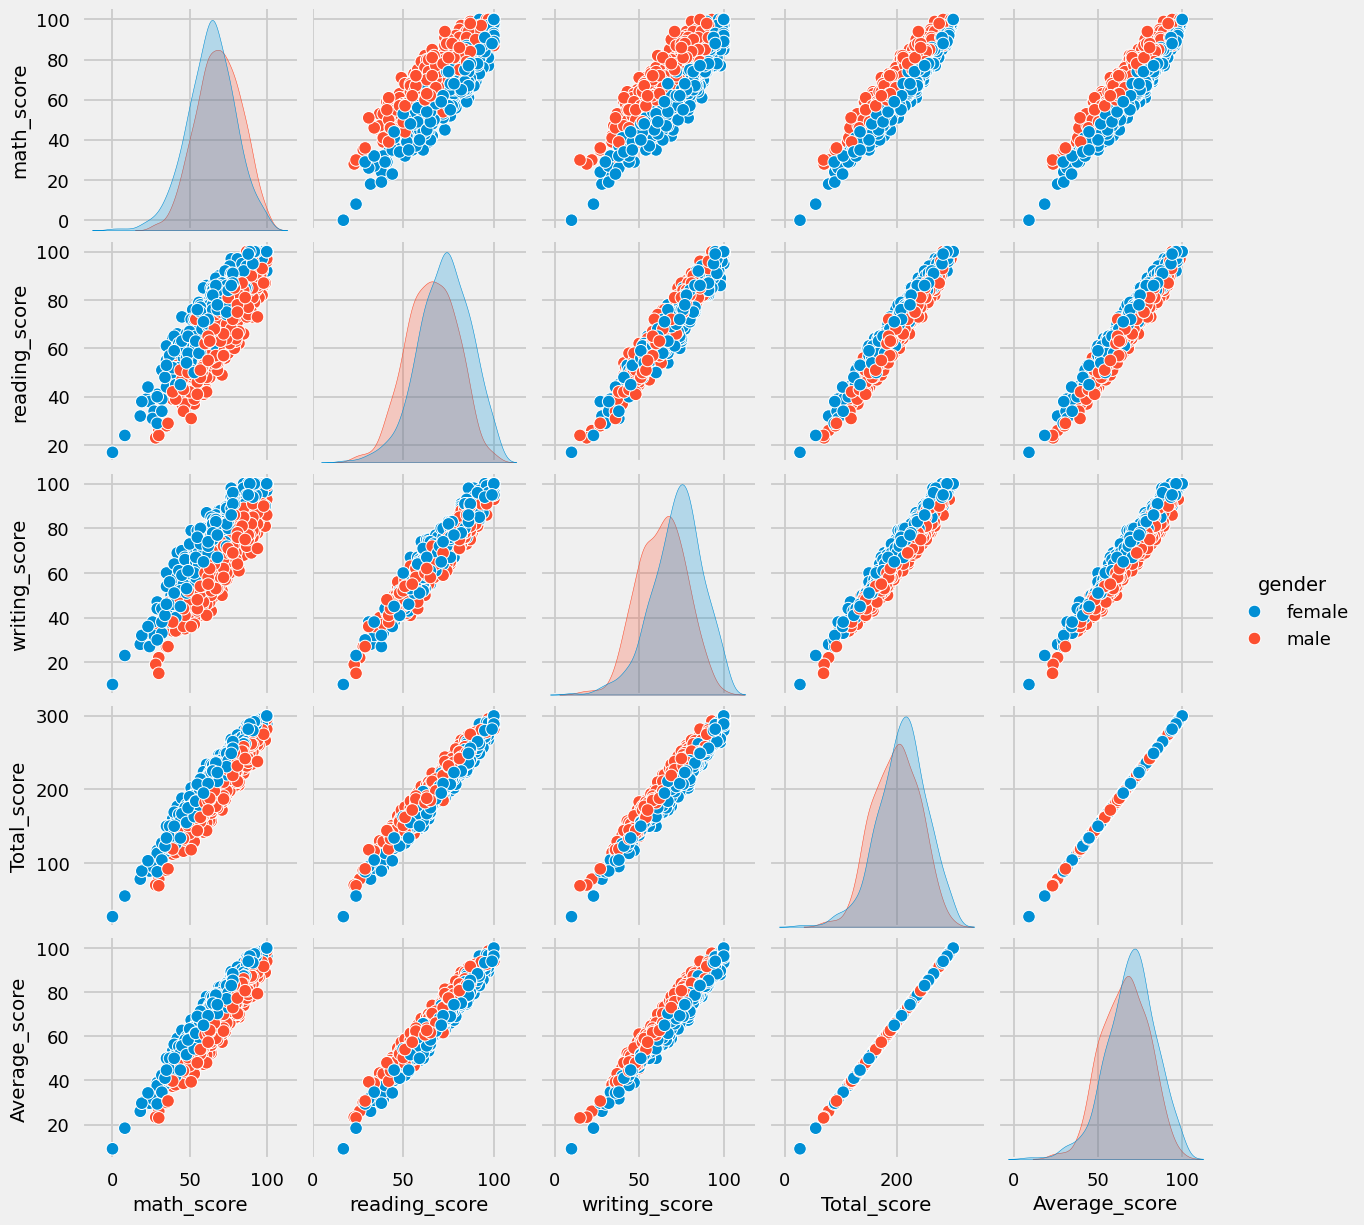

In [39]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.